In [ ]:
#6. PHASE 1 — Python Data Cleaning

In [1]:
# Step 1 - Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#  Step 2 - Load the dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# step 3 - Understand the dataset
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [7]:
# 7.Check Missing Values 
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [8]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [9]:
# 8. Handle Missing TotalCharges
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [10]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [11]:
#9. Check Duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
#df = df.drop_duplicates()

In [ ]:
# 10. Create Useful Analytical Columns

In [13]:
# Tenure bands
df["TenureBand"] = pd.cut(
    df["tenure"],
    bins=[0, 6, 12, 24, 48, 60, 72],
    labels=["0-6", "7-12", "13-24", "25-48", "49-60", "61-72"],
    include_lowest=True
)

In [14]:
#Senior Citizen Label
df["SeniorCitizenLabel"] = df["SeniorCitizen"].map({
    0: "Non-Senior",
    1: "Senior"
})

In [15]:
# Churn Flag 
df["ChurnFlag"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [16]:
# 11. Save Clean Data
df.to_csv(
    "telco_customer_churn_cleaned.csv",
    index=False
)

In [ ]:
# 12. PHASE 2 — Python Exploratory Data Analysis

In [17]:
# 13. Overall Churn
churn_count = df["Churn"].value_counts()

print(churn_count)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [18]:
churn_rate = (
    df["ChurnFlag"].mean() * 100
)

print(f"Churn Rate: {churn_rate:.2f}%")


Churn Rate: 26.54%


In [19]:
# 14. Churn by Contract
contract_churn = (
    df.groupby("Contract")["ChurnFlag"]
    .mean()
    .sort_values(ascending=False) * 100
)

print(contract_churn)

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: ChurnFlag, dtype: float64


In [20]:
# 15. Churn by Tenure
tenure_churn = (
    df.groupby("TenureBand", observed=False)["ChurnFlag"]
    .mean() * 100
)

print(tenure_churn)

TenureBand
0-6      52.937205
7-12     35.886525
13-24    28.710938
25-48    20.388959
49-60    14.423077
61-72     6.609808
Name: ChurnFlag, dtype: float64


In [21]:
# 16. Churn by Payment Method
payment_churn = (
    df.groupby("PaymentMethod")["ChurnFlag"]
    .mean()
    .sort_values(ascending=False) * 100
)

print(payment_churn)

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: ChurnFlag, dtype: float64


In [22]:
# 17. Churn by Internet Service
internet_churn = (
    df.groupby("InternetService")["ChurnFlag"]
    .mean()
    .sort_values(ascending=False) * 100
)

print(internet_churn)

InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: ChurnFlag, dtype: float64


In [23]:
# 18. Tech Support Analysis
tech_support = (
    df.groupby("TechSupport")["ChurnFlag"]
    .mean() * 100
)

print(tech_support)

TechSupport
No                     41.635474
No internet service     7.404980
Yes                    15.166341
Name: ChurnFlag, dtype: float64


In [24]:
# 19. Online Security Analysis
security = (
    df.groupby("OnlineSecurity")["ChurnFlag"]
    .mean() * 100
)

print(security)

OnlineSecurity
No                     41.766724
No internet service     7.404980
Yes                    14.611194
Name: ChurnFlag, dtype: float64


Task was destroyed but it is pending!
task: <Task pending name='Task-254' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Python314\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-255' coro=<Kernel.shell_main() running at C:\Python314\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Python314\Lib\site-packages\zmq\eventloop\zmqstream.py:564]>
C:\Python314\Lib\site-packages\matplotlib\_api\__init__.py:123: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  def check_isinstance(types, /, **kwargs):
Task was destroyed but it is pending!
task: <Task pending name='Task-255' coro=<Kernel.shell_main() running at C:\Python314\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


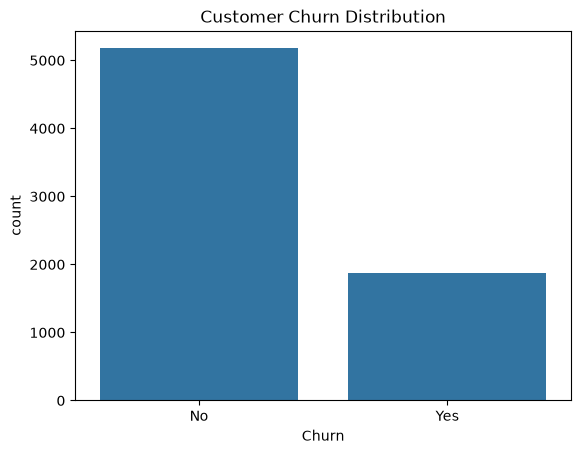

In [25]:
# 20. Python Visualization
# Chart 1
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.show()

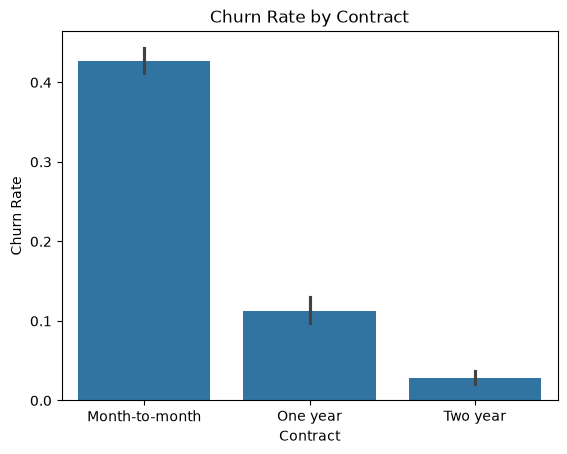

In [26]:
# Cart 2
sns.barplot(
    data=df,
    x="Contract",
    y="ChurnFlag"
)

plt.title("Churn Rate by Contract")
plt.ylabel("Churn Rate")
plt.show()

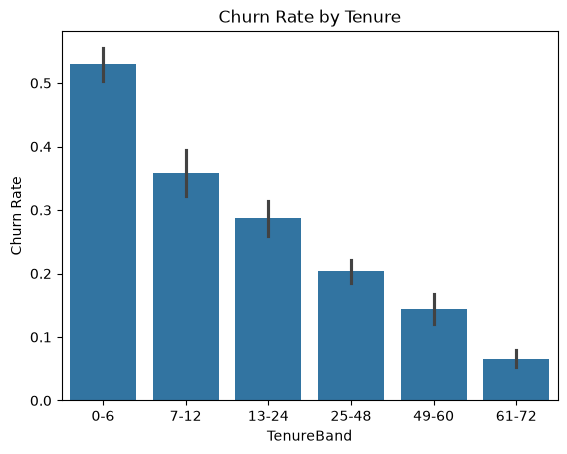

In [27]:
#Chart 3
sns.barplot(
    data=df,
    x="TenureBand",
    y="ChurnFlag"
)

plt.title("Churn Rate by Tenure")
plt.ylabel("Churn Rate")
plt.show()

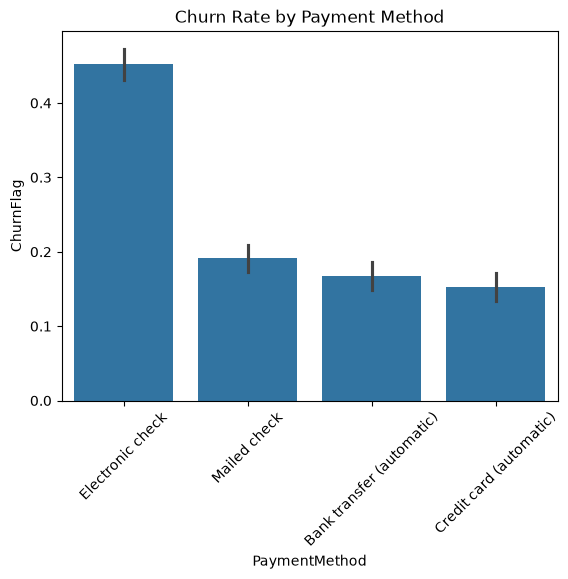

In [28]:
#Chart 4
sns.barplot(
    data=df,
    x="PaymentMethod",
    y="ChurnFlag"
)

plt.xticks(rotation=45)
plt.title("Churn Rate by Payment Method")
plt.show()